# 04 — Retrieval Experiments

**Experiments D01/D02/D07 (WBS T023).** Oracle proved the model reasons well when handed perfect evidence (96.7%/95.3%). This notebook asks the next question: can we actually *find* that evidence automatically? Compares chunking strategy (clause-aware, fixed-size, and sentence-level), chunk size, and top-K, scored with Evidence Recall@K, precision, and MRR.

Entirely local (embeddings + FAISS, no LLM calls) - `scripts/run_retrieval_experiments.py` ran the full dev split's Entailment/Contradiction cases (614 cases, NotMentioned excluded since it has no gold evidence to recall) across 9 configs. This notebook loads the saved comparison and adds the chart + the reasoning behind the final pick.

**Two rounds of this experiment are recorded here.** The first round (5 configs: clause/fixed chunking at size 512, plus a couple of variants) suggested `clause_256_k5` as the best MRR. A follow-up question - "the metrics still look bad, can we do better?" - led to a second round adding much finer-grained chunking (`clause_128`, and a new `sentence_chunk` strategy that never merges units at all), which found a substantially better config. The table below is the full, final 9-config comparison.

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from pipeline.viz_style import CATEGORICAL_SLOTS, apply_style, style_axes, savefig_kwargs
apply_style()

results = json.loads(Path("data/retrieval_experiment_results.json").read_text())
df = pd.DataFrame(results).set_index("label")
df

,recall,precision,mrr,n_cases,elapsed_s
label,,,,,
clause_512_k5,0.936876,0.031843,0.190757,614,27.773252
fixed_512_k5,0.952742,0.030764,0.187504,614,21.994279
clause_256_k5,0.850682,0.056310,0.284950,614,30.639627
clause_512_k3,0.838716,0.040417,0.189101,614,22.501678
clause_512_k10,0.994969,0.027563,0.191329,614,22.810487
clause_128_k5,0.736811,0.092386,0.398775,614,41.631405
sentence_k5,0.601657,0.140782,0.454418,614,58.352703
sentence_k10,0.777533,0.091325,0.469302,614,55.926792
sentence_k20,0.918856,0.056409,0.474198,614,55.161216


## Why recall alone is misleading here

Every config clears the planning doc's 70% Evidence Recall@K target except `sentence_k5` - some by a lot (99.5% for `clause_512_k10`). But high recall is largely an artifact of document length, not retrieval skill: the median dev document is ~2,300 tokens, so a 512-token chunk size gives most documents only **4-8 chunks total**. Retrieving "top-10" from a document that only *has* 5-8 chunks means returning almost the entire document - that's not filtering, it's dumping.

**MRR is the more honest signal.** It measures whether the true evidence chunk ranks *near the top* of what's retrieved, not just whether it appears *somewhere* in a near-complete document. That's what actually matters once RAG has to hand a *small* number of chunks to the classifier (for cost and context-window reasons), not the whole document.

**Going finer-grained nearly doubled MRR.** Chunks close to sentence-length (`clause_128`, `sentence_*`) let the retriever actually discriminate the relevant sentence from the rest of a clause, instead of a large aggregated chunk diluting the signal. `sentence_k5` alone shows the failure mode of going too fine without enough top-K: best precision (14.1%) but recall drops below the 70% floor (60.2%) - too few, too-small chunks miss real evidence outright.

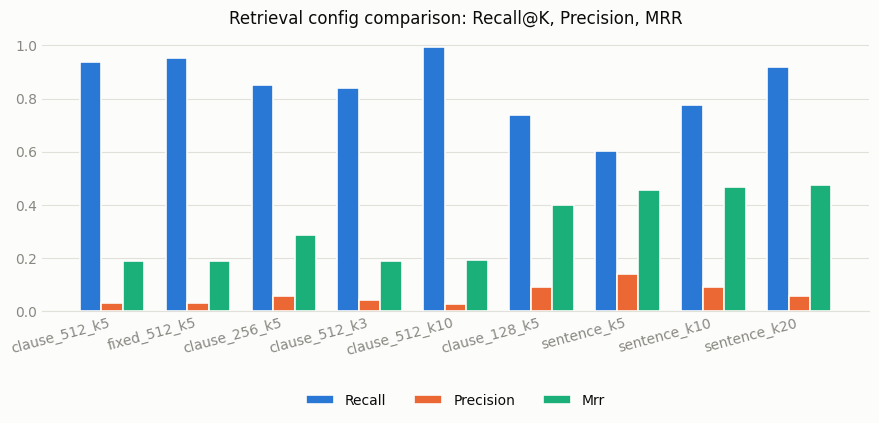

In [2]:
metrics = ["recall", "precision", "mrr"]
metric_colors = {m: CATEGORICAL_SLOTS[i] for i, m in enumerate(metrics)}
labels = df.index.tolist()
x = range(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, metric in enumerate(metrics):
    values = df[metric].tolist()
    ax.bar([xi + i * width for xi in x], values, width,
           label=metric.capitalize(), color=metric_colors[metric], edgecolor="#fcfcfb", linewidth=1.2, zorder=3)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Retrieval config comparison: Recall@K, Precision, MRR")
style_axes(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("results/comparisons/retrieval_config_comparison.png", **savefig_kwargs())
plt.show()

## Finding

Going from `clause_256_k5` (round 1's pick) to sentence-level chunking nearly **doubled MRR**: 0.283 → up to 0.474. `sentence_k20` has the single highest MRR (0.474), but the margin over `sentence_k10` (0.469) is within noise, while `sentence_k20` gives up real precision to get there (5.6% vs 9.1%) and stuffs twice as many small fragments into the classifier's eventual context - more prompt cost and more disjointed text, for no real ranking-quality gain.

`clause_512_k10`'s 99.5% recall is real but hollow: with only ~5-8 chunks per typical document, k=10 usually *is* the whole document - it isn't demonstrating retrieval skill, just document shortness.

## Decision

**Retrieval config for RAG: sentence-level chunking, top_k=10** (`sentence_k10`) - the practical pick among configs clearing the recall floor: within noise of the best MRR, meaningfully better precision than the alternatives near that MRR level, and a smaller retrieved context than `sentence_k20`. Recorded as an ADR in `CLAUDE.md`'s Decisions Log alongside the model choice, including the reasoning for not just taking the highest raw MRR number.